# 01 — Dataset Preparation

Parses `final-annotations.json` and produces:
- **YOLO-format dataset** (`data/yolo_dataset_cv/`) — for YOLOv8 & OC-SORT
- **MOT-format dataset** (`data/mot_dataset/`) — for MOTR
- **Long-video stitched sequences** (`data/mot_dataset_longvideo/`) — shared evaluation benchmark
- **Label-stratified 5-fold CV splits + 20% test set** (stratified by object class, not game ID)

### Split Strategy

Chunks are split at the **individual chunk level** (not by game source), stratified to
balance the 9 object class distribution across train / val / test.  
A greedy multi-label stratification algorithm assigns each chunk to the fold where it
reduces the current class imbalance the most.

Long-video stitched sequences use the same GT format (MOT17) for all three model
architectures — models output MOT predictions, evaluated against the same GT file.

Run once before any training notebook.

## 0 — Configuration

In [5]:
from pathlib import Path

REPO_ROOT        = Path("../")
ANNOTATIONS_JSON = REPO_ROOT / "data/labels/final-annotations.json"
CHUNKS_DIR       = REPO_ROOT / "data/processed/labelstudiochunks"
YOLO_DIR         = REPO_ROOT / "data/yolo_dataset_cv_reduced"
MOT_DIR          = REPO_ROOT / "data/mot_dataset"
MOT_LV_DIR       = REPO_ROOT / "data/mot_dataset_longvideo"
SPLITS_DIR       = REPO_ROOT / "data/splits"

CLASSES = ["Boost", "Charge", "Defense", "Glide", "HP",
           "Offense", "Top Speed", "Turn", "Weight"]

# Interpolation settings
# MOT/video models benefit from dense per-frame GT (INTERPOLATE=True)
# YOLO trains on keyframes only — interpolated frames are synthetic and inflate
# the dataset ~2.5x with near-duplicate images, slowing training significantly.
INTERPOLATE      = True    # used for MOT export & chunk-level class histogram
YOLO_INTERPOLATE = False   # False = keyframes only for YOLO (~41k vs ~100k frames)

# Max background (empty-label) frames exported per negative chunk for YOLO.
# Negative chunks have ~300 frames each; exporting all would add ~10k near-
# duplicate background frames. Sample evenly instead.
YOLO_MAX_BG_FRAMES_PER_CHUNK = 30

# Max annotated frames exported per annotated chunk for YOLO.
# Each annotated chunk has ~85 keyframes on average. Setting this lower (e.g. 20)
# dramatically reduces dataset size while keeping class diversity.
# None = no limit (use all keyframes)
YOLO_MAX_ANN_FRAMES_PER_CHUNK = 20

N_FOLDS       = 5
TEST_FRACTION = 0.20   # ~20% of chunks held out as test

# Long-video config
LONG_VIDEO_SEC       = 60     # target clip length (seconds)
BOUNDARY_DIST_THRESH = 20.0   # % of frame size for track boundary matching

print("Config OK")
print(f"  Classes   : {CLASSES}")
print(f"  Test frac : {TEST_FRACTION}")
print(f"  N folds   : {N_FOLDS}")


Config OK
  Classes   : ['Boost', 'Charge', 'Defense', 'Glide', 'HP', 'Offense', 'Top Speed', 'Turn', 'Weight']
  Test frac : 0.2
  N folds   : 5


## 1 — Imports & helpers

In [6]:
import json, re, shutil, random
from collections import defaultdict
from pathlib import Path
import numpy as np
import cv2
from tqdm.auto import tqdm


def get_class_id(label):
    if label not in CLASSES:
        raise ValueError(f"Unknown label '{label}'")
    return CLASSES.index(label)


def interpolate_sequence(sequence, interpolate=True):
    keyframes = sorted(
        [kf for kf in sequence if kf.get("enabled", True)],
        key=lambda kf: kf["frame"]
    )
    frame_map = {}
    for i, kf in enumerate(keyframes):
        frame_map[kf["frame"]] = dict(kf)
        if interpolate and i + 1 < len(keyframes):
            nf = keyframes[i + 1]
            f0, f1 = kf["frame"], nf["frame"]
            for step in range(1, f1 - f0):
                t = step / (f1 - f0)
                frame_map[f0 + step] = {
                    "frame":   f0 + step,
                    "x":       kf["x"]      + t * (nf["x"]      - kf["x"]),
                    "y":       kf["y"]      + t * (nf["y"]       - kf["y"]),
                    "width":   kf["width"]  + t * (nf["width"]   - kf["width"]),
                    "height":  kf["height"] + t * (nf["height"]  - kf["height"]),
                    "enabled": True,
                }
    return frame_map


def vid_filename(url):
    m = re.search(r"([^/?]+\.mp4)", url, re.IGNORECASE)
    return m.group(1) if m else None


def source_of(fname):
    m = re.match(r"([A-Za-z]+_?G\d)", fname)
    return m.group(1) if m else None


def chunk_of(fname):
    m = re.search(r"chunk_(\d+)", fname)
    return int(m.group(1)) if m else 0


print("Helpers ready.")


Helpers ready.


## 2 — Parse annotations

In [7]:
with open(ANNOTATIONS_JSON) as f:
    raw = json.load(f)
print(f"Loaded {len(raw)} raw tasks")

parsed      = []   # annotated chunks (have at least one track)
unannotated = []   # unannotated chunks (empty labels — valid negatives)

for task in raw:
    fname = vid_filename(task.get("data", {}).get("video", ""))
    if not fname:
        continue   # no video URL — skip entirely

    source    = source_of(fname)
    chunk_num = chunk_of(fname)
    anns      = task.get("annotations", [])
    has_results = bool(anns and anns[0].get("result"))

    # ── Unannotated chunk: valid negative example ─────────────────────────
    if not has_results:
        unannotated.append({
            "source": source, "chunk_num": chunk_num, "video_filename": fname,
            "frame_annotations": {},
            "frame_annotations_kf": {},
            "track_annotations": [],
            "class_counts":       {c: 0 for c in CLASSES},
            "frame_class_counts": {c: 0 for c in CLASSES},
            "frames_count": 0,
            "fps": 30.0,
            "is_negative": True,
        })
        continue

    # ── Annotated chunk ───────────────────────────────────────────────────
    frame_anns    = defaultdict(list)   # interpolated (for MOT / chunk histogram)
    frame_anns_kf = defaultdict(list)   # keyframes only (for YOLO)
    track_anns   = []
    frames_count = 0
    fps_val      = 30.0
    tid_ctr      = 1
    class_counts       = {c: 0 for c in CLASSES}  # track count per class
    frame_class_counts = {c: 0 for c in CLASSES}  # keyframe count per class (for YOLO stratification)

    for ann in anns:
        for res in ann.get("result", []):
            if res.get("type") != "videorectangle":
                continue
            val    = res["value"]
            labels = val.get("labels", [])
            seq    = val.get("sequence", [])
            frames_count = max(frames_count, val.get("framesCount", 0))
            dur = val.get("duration", 0)
            if frames_count and dur:
                fps_val = frames_count / dur
            if not labels:
                continue
            cid       = get_class_id(labels[0])
            # Build both: keyframes-only and fully interpolated
            frame_map_interp  = interpolate_sequence(seq, interpolate=True)
            frame_map_kf_only = interpolate_sequence(seq, interpolate=False)
            class_counts[labels[0]] += 1
            frame_class_counts[labels[0]] += len(frame_map_kf_only)
            track_frames = []
            for fn, kf in sorted(frame_map_interp.items()):
                if not kf.get("enabled", True):
                    continue
                cx = max(0, min(1, (kf["x"] + kf["width"]  / 2) / 100))
                cy = max(0, min(1, (kf["y"] + kf["height"] / 2) / 100))
                w  = max(0, min(1, kf["width"]  / 100))
                h  = max(0, min(1, kf["height"] / 100))
                frame_anns[fn].append(f"{cid} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
                track_frames.append({
                    "frame": fn,
                    "x_pct": kf["x"], "y_pct": kf["y"],
                    "w_pct": kf["width"], "h_pct": kf["height"],
                    "class_id": cid, "label": labels[0],
                })
            # Keyframe-only annotations for YOLO export
            for fn, kf in sorted(frame_map_kf_only.items()):
                if not kf.get("enabled", True):
                    continue
                cx = max(0, min(1, (kf["x"] + kf["width"]  / 2) / 100))
                cy = max(0, min(1, (kf["y"] + kf["height"] / 2) / 100))
                w  = max(0, min(1, kf["width"]  / 100))
                h  = max(0, min(1, kf["height"] / 100))
                frame_anns_kf[fn].append(f"{cid} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
            if track_frames:
                track_anns.append({
                    "track_id": tid_ctr, "label": labels[0], "class_id": cid,
                    "frames": track_frames,
                })
                tid_ctr += 1

    parsed.append({
        "source": source, "chunk_num": chunk_num, "video_filename": fname,
        "frame_annotations":    dict(frame_anns),     # interpolated — for MOT
        "frame_annotations_kf": dict(frame_anns_kf),  # keyframes only — for YOLO
        "track_annotations": track_anns,
        "class_counts":       class_counts,        # track count — for MOT stratification
        "frame_class_counts": frame_class_counts,  # keyframe count — for YOLO stratification
        "frames_count": frames_count,
        "fps": fps_val,
        "is_negative": False,
    })

from collections import Counter
src_counts = Counter(p["source"] for p in parsed)
print(f"Annotated chunks  : {len(parsed)} across {len(src_counts)} sources")
print(f"Unannotated chunks: {len(unannotated)} (negative examples, will be spread across splits)")
for s, n in sorted(src_counts.items(), key=lambda x: (x[0] is None, x[0])):
    print(f"  {s}: {n} annotated chunks")


Loaded 514 raw tasks
Annotated chunks  : 482 across 14 sources
Unannotated chunks: 32 (negative examples, will be spread across splits)
  AY_G1: 35 annotated chunks
  AY_G2: 33 annotated chunks
  AY_G3: 33 annotated chunks
  Frozoha_G1: 36 annotated chunks
  Frozoha_G2: 35 annotated chunks
  ParTwo_G1: 33 annotated chunks
  ParTwo_G2: 36 annotated chunks
  Puka_G1: 37 annotated chunks
  Puka_G2: 35 annotated chunks
  SerpentBoi_G1: 36 annotated chunks
  SerpentBoi_G2: 33 annotated chunks
  SerpentBoi_G3: 33 annotated chunks
  SquidmanG1: 32 annotated chunks
  SquidmanG2: 35 annotated chunks


## 2b — Label Distribution

Counts of **annotation tracks** and **keyframes** per class across the entire dataset.

Total annotation tracks    : 2,169
Total keyframe appearances : 49,213

    class  tracks  track_pct  keyframes  keyframe_pct
Top Speed     295       13.6       7659          15.6
  Offense     283       13.0       6123          12.4
    Glide     268       12.4       4379           8.9
   Charge     267       12.3       6031          12.3
     Turn     238       11.0       5564          11.3
    Boost     233       10.7       5693          11.6
  Defense     212        9.8       5092          10.3
       HP     195        9.0       4691           9.5
   Weight     178        8.2       3981           8.1


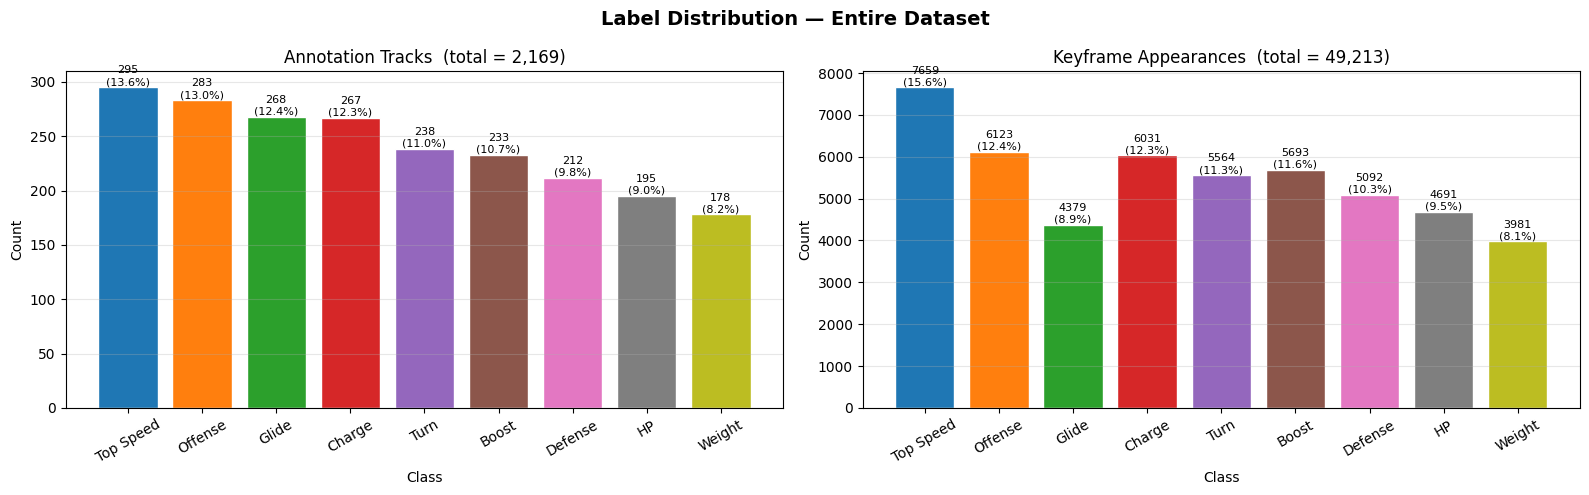

Saved: ../data/label_distribution.png


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Aggregate counts across all annotated chunks ──────────────────────────
track_counts = {c: 0 for c in CLASSES}   # unique track count
kf_counts    = {c: 0 for c in CLASSES}   # keyframe appearances

for chunk in parsed:
    for c in CLASSES:
        track_counts[c] += chunk["class_counts"].get(c, 0)
        kf_counts[c]    += chunk["frame_class_counts"].get(c, 0)

total_tracks = sum(track_counts.values())
total_kf     = sum(kf_counts.values())

df_dist = pd.DataFrame({
    "class":        CLASSES,
    "tracks":       [track_counts[c] for c in CLASSES],
    "track_pct":    [track_counts[c] / max(total_tracks, 1) * 100 for c in CLASSES],
    "keyframes":    [kf_counts[c]    for c in CLASSES],
    "keyframe_pct": [kf_counts[c]    / max(total_kf,     1) * 100 for c in CLASSES],
})
df_dist = df_dist.sort_values("tracks", ascending=False).reset_index(drop=True)

print(f"Total annotation tracks    : {total_tracks:,}")
print(f"Total keyframe appearances : {total_kf:,}")
print()
print(df_dist.to_string(index=False, float_format=lambda x: f"{x:.1f}"))

# ── Bar chart ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Label Distribution — Entire Dataset", fontsize=14, fontweight="bold")

colors = plt.cm.tab10.colors

for ax, col, pct_col, total, title in [
    (axes[0], "tracks",   "track_pct",   total_tracks, f"Annotation Tracks  (total = {total_tracks:,})"),
    (axes[1], "keyframes","keyframe_pct", total_kf,     f"Keyframe Appearances  (total = {total_kf:,})"),
]:
    bars = ax.bar(df_dist["class"], df_dist[col],
                  color=[colors[i % len(colors)] for i in range(len(df_dist))],
                  edgecolor="white")
    for bar, val, pct in zip(bars, df_dist[col], df_dist[pct_col]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f"{int(val)}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=8)
    ax.set_title(title)
    ax.set_ylabel("Count"); ax.set_xlabel("Class")
    ax.tick_params(axis="x", rotation=30); ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
out_path = REPO_ROOT / "data" / "label_distribution.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")


## 3 — Label-stratified splits

Two stratifications are computed:

**MOT split** (`class_counts` = tracks per class): used for MOT/video model exports.
**YOLO split** (`frame_class_counts` = keyframes per class): used for YOLO image export.
Unannotated chunks are distributed evenly in both splits proportional to
target fractions.

The YOLO split treats "background" frames as an implicit extra class — since
negative chunks all have zero class counts, `greedy_stratify` will distribute
them proportionally via `distribute_negatives`. The background:foreground ratio
is controlled by `YOLO_MAX_BG_FRAMES_PER_CHUNK` in configuration.

In [4]:
def greedy_stratify(chunks, n_bins, target_fracs, count_key="class_counts", seed=42):
    # Greedy multi-label stratification.
    # count_key: 'class_counts' for track-level, 'frame_class_counts' for frame-level
    rng = random.Random(seed)
    shuffled = chunks[:]
    rng.shuffle(shuffled)
    total_class = {c: sum(ch[count_key][c] for ch in shuffled) for c in CLASSES}
    target  = np.array([[total_class[c] * frac for c in CLASSES]
                         for frac in target_fracs])
    current = np.zeros_like(target)
    bins    = [[] for _ in range(n_bins)]
    for chunk in shuffled:
        vec = np.array([chunk[count_key].get(c, 0) for c in CLASSES], dtype=float)
        scores = [np.sum((target[b] - current[b]) ** 2) -
                  np.sum((target[b] - current[b] - vec) ** 2)
                  for b in range(n_bins)]
        best = int(np.argmax(scores))
        bins[best].append(chunk)
        current[best] += vec
    return bins


def distribute_negatives(neg_chunks, n_bins, target_fracs, seed=43):
    rng = random.Random(seed)
    shuffled = neg_chunks[:]
    rng.shuffle(shuffled)
    bins   = [[] for _ in range(n_bins)]
    total  = len(shuffled)
    counts = [max(0, round(total * f)) for f in target_fracs]
    counts[-1] += total - sum(counts)
    seq = [b for b, c in enumerate(counts) for _ in range(c)]
    for chunk, b in zip(shuffled, seq):
        bins[b].append(chunk)
    return bins


n_bins   = 1 + N_FOLDS
val_frac = (1.0 - TEST_FRACTION) / N_FOLDS
fracs    = [TEST_FRACTION] + [val_frac] * N_FOLDS
print(f"Target fractions: test={fracs[0]:.2f}, each val fold={fracs[1]:.2f}")

neg_bins = distribute_negatives(unannotated, n_bins, fracs)

# ── MOT split (track-level stratification) ────────────────────────────────
mot_ann_bins  = greedy_stratify(parsed, n_bins, fracs, count_key="class_counts")
mot_all_bins  = [mot_ann_bins[i] + neg_bins[i] for i in range(n_bins)]
test_chunks   = mot_all_bins[0]
val_chunks    = mot_all_bins[1:]
fold_configs  = []
for fold in range(N_FOLDS):
    train_chunks = [c for i, b in enumerate(mot_all_bins)
                    if i != 0 and i != fold + 1 for c in b]
    fold_configs.append({"fold": fold, "train": train_chunks,
                         "val": val_chunks[fold], "test": test_chunks})

# ── YOLO split (frame-level stratification) ───────────────────────────────
yolo_ann_bins  = greedy_stratify(parsed, n_bins, fracs, count_key="frame_class_counts", seed=44)
yolo_all_bins  = [yolo_ann_bins[i] + neg_bins[i] for i in range(n_bins)]
yolo_test_chunks  = yolo_all_bins[0]
yolo_val_chunks   = yolo_all_bins[1:]
yolo_fold_configs = []
for fold in range(N_FOLDS):
    train_chunks = [c for i, b in enumerate(yolo_all_bins)
                    if i != 0 and i != fold + 1 for c in b]
    yolo_fold_configs.append({"fold": fold, "train": train_chunks,
                               "val": yolo_val_chunks[fold], "test": yolo_test_chunks})

def split_summary(chunks):
    ann = sum(1 for c in chunks if not c.get("is_negative"))
    neg = sum(1 for c in chunks if c.get("is_negative"))
    return f"{len(chunks)} chunks ({ann} annotated, {neg} negative)"

def estimate_yolo_frames(chunks):
    ann_frames = sum(len(c.get("frame_annotations_kf", c["frame_annotations"])) for c in chunks
                     if not c.get("is_negative"))
    bg_frames  = sum(min(YOLO_MAX_BG_FRAMES_PER_CHUNK, 1)  # placeholder; actual count needs video
                     for c in chunks if c.get("is_negative")) * YOLO_MAX_BG_FRAMES_PER_CHUNK
    neg_approx = sum(1 for c in chunks if c.get("is_negative")) * YOLO_MAX_BG_FRAMES_PER_CHUNK
    return ann_frames, neg_approx

print(f"\nMOT split (track-level stratification):")
print(f"  Test set    : {split_summary(test_chunks)}")
for fold in range(N_FOLDS):
    print(f"  Fold {fold} val : {split_summary(val_chunks[fold])}  |  "
          f"train: {split_summary(fold_configs[fold]['train'])}")

print(f"\nYOLO split (frame-level stratification):")
print(f"  Test set    : {split_summary(yolo_test_chunks)}")
for fold in range(N_FOLDS):
    af, nf = estimate_yolo_frames(yolo_fold_configs[fold]["train"])
    print(f"  Fold {fold} val : {split_summary(yolo_val_chunks[fold])}  |  "
          f"train: {split_summary(yolo_fold_configs[fold]['train'])}  "
          f"(~{af} ann frames + ~{nf} bg frames)")

total_ann_frames = sum(len(c.get("frame_annotations_kf", {})) for c in parsed)
total_bg_frames  = len(unannotated) * YOLO_MAX_BG_FRAMES_PER_CHUNK
print(f"\nEstimated YOLO dataset size (YOLO_INTERPOLATE={YOLO_INTERPOLATE}):")
print(f"  Annotated frames: ~{total_ann_frames:,} (keyframes only)")
print(f"  Background frames: ~{total_bg_frames:,} ({len(unannotated)} neg chunks × {YOLO_MAX_BG_FRAMES_PER_CHUNK} frames)")
print(f"  Total: ~{total_ann_frames + total_bg_frames:,} frames")


Target fractions: test=0.20, each val fold=0.16

MOT split (track-level stratification):
  Test set    : 101 chunks (95 annotated, 6 negative)
  Fold 0 val : 79 chunks (74 annotated, 5 negative)  |  train: 334 chunks (313 annotated, 21 negative)
  Fold 1 val : 81 chunks (76 annotated, 5 negative)  |  train: 332 chunks (311 annotated, 21 negative)
  Fold 2 val : 85 chunks (80 annotated, 5 negative)  |  train: 328 chunks (307 annotated, 21 negative)
  Fold 3 val : 80 chunks (75 annotated, 5 negative)  |  train: 333 chunks (312 annotated, 21 negative)
  Fold 4 val : 88 chunks (82 annotated, 6 negative)  |  train: 325 chunks (305 annotated, 20 negative)

YOLO split (frame-level stratification):
  Test set    : 105 chunks (99 annotated, 6 negative)
  Fold 0 val : 77 chunks (72 annotated, 5 negative)  |  train: 332 chunks (311 annotated, 21 negative)  (~26213 ann frames + ~630 bg frames)
  Fold 1 val : 87 chunks (82 annotated, 5 negative)  |  train: 322 chunks (301 annotated, 21 negative)  (

## 4 — Verify class balance across splits

MOT split — class fraction per split (track-level):
         Boost  Charge  Defense  Glide     HP  Offense  Top Speed   Turn  Weight
split                                                                           
FULL     1.000   1.000    1.000  1.000  1.000    1.000      1.000  1.000   1.000
test     0.197   0.202    0.203  0.201  0.205    0.201      0.207  0.197   0.202
val_0    0.163   0.161    0.160  0.157  0.159    0.159      0.156  0.168   0.152
train_0  0.639   0.637    0.637  0.642  0.636    0.640      0.637  0.634   0.646
val_1    0.155   0.157    0.165  0.153  0.159    0.159      0.156  0.155   0.157
train_1  0.648   0.640    0.632  0.646  0.636    0.640      0.637  0.647   0.640
val_2    0.159   0.161    0.160  0.164  0.164    0.163      0.169  0.160   0.163
train_2  0.644   0.637    0.637  0.634  0.631    0.636      0.624  0.643   0.635
val_3    0.167   0.161    0.160  0.164  0.159    0.163      0.153  0.155   0.163
train_3  0.635   0.637    0.637  0.634  0.636    0.636   

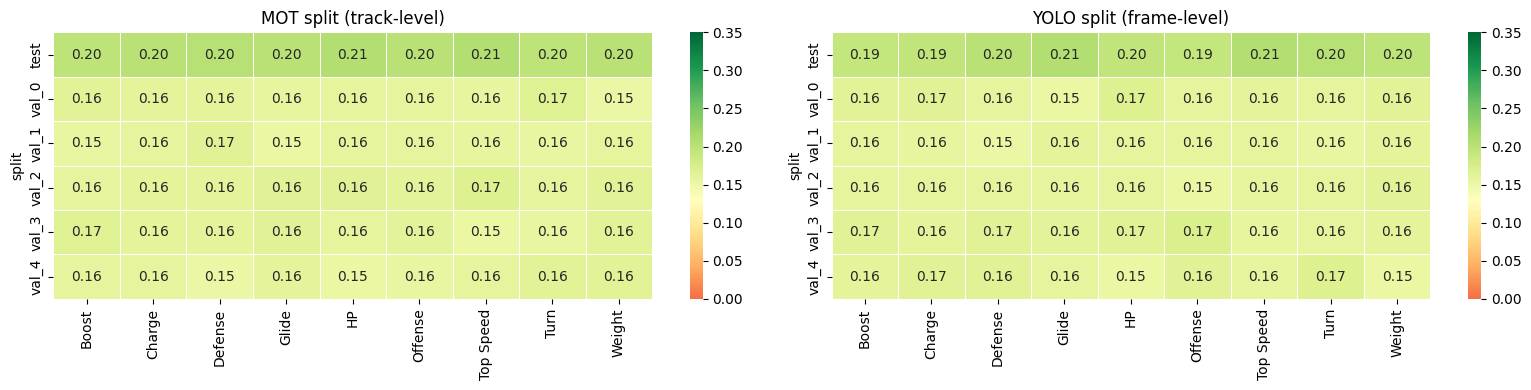

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def class_dist(chunks, key="class_counts"):
    totals = {c: 0 for c in CLASSES}
    for ch in chunks:
        for c in CLASSES:
            totals[c] += ch[key].get(c, 0)
    return totals

all_chunks = parsed + unannotated

# MOT split balance (track-level)
rows = [{"split": "FULL", **class_dist(all_chunks)},
        {"split": "test", **class_dist(test_chunks)}]
for fold in range(N_FOLDS):
    rows.append({"split": f"val_{fold}",   **class_dist(val_chunks[fold])})
    rows.append({"split": f"train_{fold}", **class_dist(fold_configs[fold]["train"])})

df_mot = pd.DataFrame(rows).set_index("split")
df_mot_norm = df_mot.div(df_mot.loc["FULL"])
print("MOT split — class fraction per split (track-level):")
print(df_mot_norm.round(3).to_string())

# YOLO split balance (frame-level)
rows2 = [{"split": "FULL", **class_dist(all_chunks, "frame_class_counts")},
         {"split": "test", **class_dist(yolo_test_chunks, "frame_class_counts")}]
for fold in range(N_FOLDS):
    rows2.append({"split": f"val_{fold}",   **class_dist(yolo_val_chunks[fold], "frame_class_counts")})
    rows2.append({"split": f"train_{fold}", **class_dist(yolo_fold_configs[fold]["train"], "frame_class_counts")})

df_yolo = pd.DataFrame(rows2).set_index("split")
df_yolo_norm = df_yolo.div(df_yolo.loc["FULL"])
print("\nYOLO split — class fraction per split (frame-level):")
print(df_yolo_norm.round(3).to_string())

print("\nBackground frame cap:")
print(f"  {len(unannotated)} negative chunks × {YOLO_MAX_BG_FRAMES_PER_CHUNK} frames = "
      f"~{len(unannotated)*YOLO_MAX_BG_FRAMES_PER_CHUNK:,} background frames")
total_ann = sum(len(c.get("frame_annotations_kf", {})) for c in parsed)
print(f"  {total_ann:,} annotated keyframes")
bg_ratio = len(unannotated)*YOLO_MAX_BG_FRAMES_PER_CHUNK / max(total_ann, 1)
print(f"  Background:foreground ratio ≈ {bg_ratio:.2f}:1")

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
show_rows = ["test"] + [f"val_{i}" for i in range(N_FOLDS)]
sns.heatmap(df_mot_norm.loc[show_rows], annot=True, fmt=".2f", cmap="RdYlGn",
            center=0.13, vmin=0, vmax=0.35, ax=axes[0], linewidths=0.5)
axes[0].set_title("MOT split (track-level)")
sns.heatmap(df_yolo_norm.loc[show_rows], annot=True, fmt=".2f", cmap="RdYlGn",
            center=0.13, vmin=0, vmax=0.35, ax=axes[1], linewidths=0.5)
axes[1].set_title("YOLO split (frame-level)")
plt.tight_layout()
SPLITS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(SPLITS_DIR.parent / "split_balance_heatmap.png", dpi=120)
plt.show()


## 5 — Save split config

In [31]:
split_meta = {
    "strategy":           "greedy_multilabel_stratification",
    "test_fraction":      TEST_FRACTION,
    "n_folds":            N_FOLDS,
    "classes":            CLASSES,
    "total_chunks":       len(all_chunks),
    "annotated_chunks":   len(parsed),
    "unannotated_chunks": len(unannotated),
    "yolo_interpolate":   YOLO_INTERPOLATE,
    "yolo_max_bg_frames": YOLO_MAX_BG_FRAMES_PER_CHUNK,
    # MOT split (track-level stratification)
    "mot_test_chunks":   [c["video_filename"] for c in test_chunks],
    "mot_folds": [
        {"fold": fold,
         "train_chunks": [c["video_filename"] for c in fold_configs[fold]["train"]],
         "val_chunks":   [c["video_filename"] for c in val_chunks[fold]]}
        for fold in range(N_FOLDS)
    ],
    # YOLO split (frame-level stratification)
    "yolo_test_chunks":  [c["video_filename"] for c in yolo_test_chunks],
    "yolo_folds": [
        {"fold": fold,
         "train_chunks": [c["video_filename"] for c in yolo_fold_configs[fold]["train"]],
         "val_chunks":   [c["video_filename"] for c in yolo_val_chunks[fold]]}
        for fold in range(N_FOLDS)
    ],
}
with open(SPLITS_DIR / "splits.json", "w") as f:
    json.dump(split_meta, f, indent=2)
print(f"Saved: {SPLITS_DIR}/splits.json")


Saved: ../data/splits/splits.json


## 6 — Export YOLO-format dataset

All images and labels are written **once** to a single pool:
- `data/yolo_dataset_cv/images/<stem>_f<N>.jpg`
- `data/yolo_dataset_cv/labels/<stem>_f<N>.txt`

Per-fold `data.yaml` files reference the pool using **absolute path lists**
(`train.txt` / `val.txt` / `test.txt`), so no images are ever duplicated.
YOLO natively supports `.txt` manifest files as the `train`/`val`/`test` values.

Dataset size is controlled by:
- `YOLO_MAX_ANN_FRAMES_PER_CHUNK` — cap annotated frames per chunk (evenly sampled)
- `YOLO_MAX_BG_FRAMES_PER_CHUNK`  — cap background frames per negative chunk

In [19]:
import yaml, os

POOL_IMG = YOLO_DIR / "images"
POOL_LBL = YOLO_DIR / "labels"
POOL_IMG.mkdir(parents=True, exist_ok=True)
POOL_LBL.mkdir(parents=True, exist_ok=True)

def export_chunk_to_pool(t, chunks_dir, pool_img, pool_lbl):
    """Extract frames for one chunk into the shared pool. Returns list of abs image paths."""
    vp = chunks_dir / t["video_filename"]
    if not vp.exists():
        return []
    cap   = cv2.VideoCapture(str(vp))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    stem  = vp.stem
    paths = []

    if t.get("is_negative"):
        if total == 0:
            cap.release()
            return []
        n_bg   = min(YOLO_MAX_BG_FRAMES_PER_CHUNK, total)
        step   = max(1, total // n_bg)
        frames = list(range(0, total, step))[:n_bg]
        for idx in frames:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if not ret:
                continue
            base = f"{stem}_f{idx+1:06d}"
            img_path = pool_img / f"{base}.jpg"
            if not img_path.exists():
                cv2.imwrite(str(img_path), frame, [cv2.IMWRITE_JPEG_QUALITY, 95])
            (pool_lbl / f"{base}.txt").write_text("")
            paths.append(str(img_path.resolve()))
    else:
        frame_anns = (t["frame_annotations"]
                      if YOLO_INTERPOLATE
                      else t.get("frame_annotations_kf", t["frame_annotations"]))
        all_frames = sorted(frame_anns.items())
        # Apply per-chunk frame cap (evenly sampled)
        if YOLO_MAX_ANN_FRAMES_PER_CHUNK and len(all_frames) > YOLO_MAX_ANN_FRAMES_PER_CHUNK:
            step = len(all_frames) / YOLO_MAX_ANN_FRAMES_PER_CHUNK
            all_frames = [all_frames[int(i * step)] for i in range(YOLO_MAX_ANN_FRAMES_PER_CHUNK)]
        for fn, lines in all_frames:
            idx = fn - 1
            if idx < 0 or idx >= total:
                continue
            base = f"{stem}_f{fn:06d}"
            img_path = pool_img / f"{base}.jpg"
            if not img_path.exists():
                cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
                ret, frame = cap.read()
                if not ret:
                    continue
                cv2.imwrite(str(img_path), frame, [cv2.IMWRITE_JPEG_QUALITY, 95])
            (pool_lbl / f"{base}.txt").write_text("\n".join(lines))
            paths.append(str(img_path.resolve()))
    cap.release()
    return paths


# ── Build pool: export every unique chunk once ────────────────────────────
all_chunks = parsed + unannotated
if YOLO_DIR.exists():
    # Only clear manifests/yamls, not the pool (allow incremental re-runs)
    for p in YOLO_DIR.glob("fold_*"):
        shutil.rmtree(p)
    for p in YOLO_DIR.glob("full_train"):
        shutil.rmtree(p)
    for p in YOLO_DIR.glob("*.txt"):
        p.unlink()

chunk_paths = {}   # video_filename -> [abs image paths]
print("Building image pool (skips already-extracted frames)...")
for t in tqdm(all_chunks, desc="pool"):
    fname = t["video_filename"]
    if fname not in chunk_paths:
        chunk_paths[fname] = export_chunk_to_pool(t, CHUNKS_DIR, POOL_IMG, POOL_LBL)

total_pool = sum(len(v) for v in chunk_paths.values())
print(f"Pool: {total_pool:,} images in {POOL_IMG}")
print(f"  Settings: YOLO_MAX_ANN_FRAMES_PER_CHUNK={YOLO_MAX_ANN_FRAMES_PER_CHUNK}, "
      f"YOLO_MAX_BG_FRAMES_PER_CHUNK={YOLO_MAX_BG_FRAMES_PER_CHUNK}")

def write_manifest(chunks, manifest_path):
    paths = []
    for c in chunks:
        paths.extend(chunk_paths.get(c["video_filename"], []))
    manifest_path.write_text("\n".join(paths))
    return len(paths)

# ── Test manifest ─────────────────────────────────────────────────────────
YOLO_DIR.mkdir(exist_ok=True)
n_test = write_manifest(yolo_test_chunks, YOLO_DIR / "test.txt")
print(f"\nTest: {n_test} frames from {len(yolo_test_chunks)} chunks")

# ── Per-fold manifests + data.yaml ────────────────────────────────────────
for fc in yolo_fold_configs:
    fold = fc["fold"]
    fold_dir = YOLO_DIR / f"fold_{fold}"
    fold_dir.mkdir(exist_ok=True)
    nt = write_manifest(fc["train"], fold_dir / "train.txt")
    nv = write_manifest(fc["val"],   fold_dir / "val.txt")
    print(f"Fold {fold}: train={nt} frames  val={nv} frames")
    data_cfg = {
        "path":  str(YOLO_DIR.resolve()),
        "train": f"fold_{fold}/train.txt",
        "val":   f"fold_{fold}/val.txt",
        "test":  "test.txt",
        "nc": len(CLASSES), "names": CLASSES,
    }
    with open(fold_dir / "data.yaml", "w") as f:
        yaml.dump(data_cfg, f, default_flow_style=False, sort_keys=False)

# ── Full train manifest (all non-test) ────────────────────────────────────
full_dir = YOLO_DIR / "full_train"
full_dir.mkdir(exist_ok=True)
test_fnames = {c["video_filename"] for c in yolo_test_chunks}
tv_chunks   = [c for c in all_chunks if c["video_filename"] not in test_fnames]
nt = write_manifest(tv_chunks,        full_dir / "train.txt")
nv = write_manifest(yolo_test_chunks, full_dir / "val.txt")
data_cfg = {
    "path":  str(YOLO_DIR.resolve()),
    "train": "full_train/train.txt",
    "val":   "full_train/val.txt",
    "test":  "test.txt",
    "nc": len(CLASSES), "names": CLASSES,
}
with open(full_dir / "data.yaml", "w") as f:
    yaml.dump(data_cfg, f, default_flow_style=False, sort_keys=False)
print(f"Full train: {nt} train  {nv} val (images shared from pool, no duplication)")
print(f"\nYOLO dataset → {YOLO_DIR}")
print(f"  Pool size: {total_pool:,} images (each stored once)")
ann_pool = sum(len(chunk_paths.get(c["video_filename"],[])) for c in parsed)
bg_pool  = sum(len(chunk_paths.get(c["video_filename"],[])) for c in unannotated)
print(f"  Annotated: {ann_pool:,}  Background: {bg_pool:,}  Ratio: {bg_pool/max(ann_pool,1):.2f}:1")


Building image pool (skips already-extracted frames)...


pool:   0%|          | 0/514 [00:00<?, ?it/s]

Pool: 10,129 images in ../data/yolo_dataset_cv_reduced/images
  Settings: YOLO_MAX_ANN_FRAMES_PER_CHUNK=20, YOLO_MAX_BG_FRAMES_PER_CHUNK=30

Test: 2035 frames from 105 chunks
Fold 0: train=6596 frames  val=1498 frames
Fold 1: train=6362 frames  val=1732 frames
Fold 2: train=6502 frames  val=1592 frames
Fold 3: train=6438 frames  val=1656 frames
Fold 4: train=6478 frames  val=1616 frames
Full train: 8094 train  2035 val (images shared from pool, no duplication)

YOLO dataset → ../data/yolo_dataset_cv_reduced
  Pool size: 10,129 images (each stored once)
  Annotated: 9,192  Background: 937  Ratio: 0.10:1


### YOLO Training Tips

**Dataset size tuning** — adjust these in Section 0 to hit your time budget:

| `YOLO_MAX_ANN_FRAMES_PER_CHUNK` | `YOLO_MAX_BG_FRAMES_PER_CHUNK` | Approx total images |
|---|---|---|
| 20 (default) | 30 (default) | ~12k–15k |
| 10 | 10 | ~6k–8k |
| 5 | 5 | ~3k–4k |

Run a single fold first to benchmark; then scale as needed.

**NMS timeout** — if you see `NMS time limit exceeded` during training, add:
```python
model.train(..., max_det=20, mosaic=0.5, mixup=0.0)
```


## 7 — Export MOT-format dataset (for MOTR)

All video sequences are extracted **once** into a shared pool at
`data/mot_dataset/sequences/<stem>/`.  Per-fold split membership is recorded in
`data/mot_dataset/fold_<N>_{train,val}.txt` (one sequence name per line) and via
**symlinks** in `data/mot_dataset/fold_<N>/train/` and `.../val/` that point into
the pool.  Symlinks are cheap to create and let MOTR/TrackEval see the right
directory layout without duplicating gigabytes of frames.

In [32]:
def vid_dims(vp):
    cap = cv2.VideoCapture(str(vp))
    w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    cap.release()
    return w, h, fps


MOT_SEQ_POOL = MOT_DIR / "sequences"   # single pool of all extracted sequences

def write_mot_seq_to_pool(task, pool_dir, chunks_dir):
    """Extract one chunk into the shared MOT sequence pool. Skips if already done."""
    vp = chunks_dir / task["video_filename"]
    if not vp.exists():
        return None
    seq_dir = pool_dir / vp.stem
    img_dir = seq_dir / "img1"
    # Skip extraction if already done (incremental re-runs)
    if seq_dir.exists() and (seq_dir / "seqinfo.ini").exists():
        return vp.stem

    w, h, fps = vid_dims(vp)
    img_dir.mkdir(parents=True, exist_ok=True)
    cap   = cv2.VideoCapture(str(vp))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fi = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        fi += 1
        cv2.imwrite(str(img_dir / f"{fi:06d}.jpg"), frame,
                    [cv2.IMWRITE_JPEG_QUALITY, 95])
    cap.release()
    (seq_dir / "seqinfo.ini").write_text(
        f"[Sequence]\nname={vp.stem}\nimDir=img1\nframeRate={fps:.2f}\n"
        f"seqLength={total}\nimWidth={w}\nimHeight={h}\nimExt=.jpg\n"
    )
    gt_dir = seq_dir / "gt"
    gt_dir.mkdir(exist_ok=True)
    lines = []
    for tr in task.get("track_annotations", []):
        for kf in tr["frames"]:
            x1 = kf["x_pct"] / 100 * w
            y1 = kf["y_pct"] / 100 * h
            bw = kf["w_pct"] / 100 * w
            bh = kf["h_pct"] / 100 * h
            lines.append(
                f"{kf['frame']},{tr['track_id']},{x1:.2f},{y1:.2f},"
                f"{bw:.2f},{bh:.2f},1,{tr['class_id']+1},1"
            )
    (gt_dir / "gt.txt").write_text("\n".join(lines))
    return vp.stem


def make_split_dir(split_dir, seq_names, pool_dir):
    """Create a split directory whose contents are symlinks into the pool."""
    if split_dir.exists():
        shutil.rmtree(split_dir)
    split_dir.mkdir(parents=True)
    for name in seq_names:
        target = pool_dir / name
        link   = split_dir / name
        if target.exists():
            link.symlink_to(target.resolve())


# ── Build shared sequence pool ────────────────────────────────────────────
MOT_SEQ_POOL.mkdir(parents=True, exist_ok=True)
all_mot_chunks = parsed + unannotated

print("Building MOT sequence pool (skips already-extracted sequences)...")
mot_chunk_names = {}   # video_filename -> seq_name (or None if video missing)
for t in tqdm(all_mot_chunks, desc="MOT pool"):
    fn = t["video_filename"]
    if fn not in mot_chunk_names:
        mot_chunk_names[fn] = write_mot_seq_to_pool(t, MOT_SEQ_POOL, CHUNKS_DIR)

total_seqs = sum(1 for v in mot_chunk_names.values() if v)
print(f"MOT pool: {total_seqs} sequences in {MOT_SEQ_POOL}")

# ── Write split manifests (.txt) and symlink directories ──────────────────
def seq_names_for(chunks):
    return [mot_chunk_names[c["video_filename"]]
            for c in chunks
            if mot_chunk_names.get(c["video_filename"])]

# Test split
test_seqs = seq_names_for(test_chunks)
(MOT_DIR / "test.txt").write_text("\n".join(test_seqs))
make_split_dir(MOT_DIR / "test", test_seqs, MOT_SEQ_POOL)
print(f"Test: {len(test_seqs)} sequences")

for fc in fold_configs:
    fold = fc["fold"]
    train_seqs = seq_names_for(fc["train"])
    val_seqs   = seq_names_for(fc["val"])
    (MOT_DIR / f"fold_{fold}_train.txt").write_text("\n".join(train_seqs))
    (MOT_DIR / f"fold_{fold}_val.txt").write_text("\n".join(val_seqs))
    make_split_dir(MOT_DIR / f"fold_{fold}" / "train", train_seqs, MOT_SEQ_POOL)
    make_split_dir(MOT_DIR / f"fold_{fold}" / "val",   val_seqs,   MOT_SEQ_POOL)
    print(f"Fold {fold}: train={len(train_seqs)} val={len(val_seqs)} sequences (symlinks, no duplication)")

neg_test = sum(1 for c in test_chunks if c.get("is_negative"))
print(f"\nMOT dataset → {MOT_DIR}")
print(f"  Pool: {MOT_SEQ_POOL}")
print(f"  ({neg_test} negative sequences in test with empty gt.txt)")
print("  Per-fold dirs use symlinks — no frames are duplicated.")


Building MOT sequence pool (skips already-extracted sequences)...


MOT pool:   0%|          | 0/514 [00:00<?, ?it/s]

MOT pool: 514 sequences in ../data/mot_dataset/sequences
Test: 101 sequences
Fold 0: train=334 val=79 sequences (symlinks, no duplication)
Fold 1: train=332 val=81 sequences (symlinks, no duplication)
Fold 2: train=328 val=85 sequences (symlinks, no duplication)
Fold 3: train=333 val=80 sequences (symlinks, no duplication)
Fold 4: train=325 val=88 sequences (symlinks, no duplication)

MOT dataset → ../data/mot_dataset
  Pool: ../data/mot_dataset/sequences
  (6 negative sequences in test with empty gt.txt)
  Per-fold dirs use symlinks — no frames are duplicated.


## 8 — Build long-video stitched sequences

Merges consecutive chunks from each game source into ~60s clips with globally
consistent track IDs (matched at chunk boundaries by class + spatial proximity).
Unannotated chunks within the merged range contribute frames but no GT boxes.

Saved to `data/mot_dataset_longvideo/test/` as MOT17-format image sequences —
readable by all three model architectures (YOLO runs tracker on temp video,
MOTR reads img1 sequences natively).

For production-quality GT, re-annotate merged clips in Label Studio
(concatenate chunks with ffmpeg first — see TRAINING_PLAN.md Phase B).

In [ ]:
def merge_to_longvideo(source, tasks, chunks_dir, out_dir,
                       clip_s=60, max_clips=3):
    tasks = sorted(tasks, key=lambda t: t["chunk_num"])
    chunk_info = []
    offset = 0
    for t in tasks:
        vp = chunks_dir / t["video_filename"]
        if not vp.exists():
            continue
        w, h, fps = vid_dims(vp)
        cap = cv2.VideoCapture(str(vp))
        fc  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        cap.release()
        chunk_info.append({"task": t, "vp": vp, "offset": offset,
                           "fc": fc, "fps": fps, "w": w, "h": h})
        offset += fc

    if not chunk_info:
        return
    fps  = chunk_info[0]["fps"]
    w, h = chunk_info[0]["w"], chunk_info[0]["h"]
    fpclip = int(clip_s * fps)
    total  = sum(c["fc"] for c in chunk_info)
    starts = list(range(0, total - fpclip, fpclip))

    for ci_idx, start in enumerate(starts[:max_clips]):
        end      = start + fpclip
        seq_name = f"{source}_clip_{ci_idx:02d}"
        seq_dir  = out_dir / seq_name
        img_dir  = seq_dir / "img1"
        img_dir.mkdir(parents=True, exist_ok=True)

        local_f = 0
        for ci in chunk_info:
            cap = cv2.VideoCapture(str(ci["vp"]))
            for fi in range(ci["fc"]):
                gf = ci["offset"] + fi + 1
                if start < gf <= end:
                    cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
                    ret, frame = cap.read()
                    if ret:
                        local_f += 1
                        cv2.imwrite(str(img_dir / f"{local_f:06d}.jpg"),
                                    frame, [cv2.IMWRITE_JPEG_QUALITY, 95])
            cap.release()

        gid = 1
        all_tracks = []
        prev_active = []

        for ci in chunk_info:
            if ci["offset"] + ci["fc"] <= start or ci["offset"] >= end:
                continue
            # Skip unannotated chunks for GT — they add frames but no tracks
            if ci["task"].get("is_negative"):
                prev_active = []
                continue
            chunk_tracks = []
            for tr in ci["task"]["track_annotations"]:
                clip_frames = []
                for kf in tr["frames"]:
                    gf = ci["offset"] + kf["frame"]
                    lf = gf - start
                    if 0 < lf <= fpclip:
                        clip_frames.append({
                            "lf": lf,
                            "x_pct": kf["x_pct"], "y_pct": kf["y_pct"],
                            "w_pct": kf["w_pct"], "h_pct": kf["h_pct"],
                            "class_id": kf["class_id"],
                        })
                if clip_frames:
                    chunk_tracks.append({"class_id": tr["class_id"],
                                         "frames": clip_frames})

            used_prev = set()
            assigned  = {}
            order = sorted(range(len(chunk_tracks)),
                           key=lambda ti: chunk_tracks[ti]["frames"][0]["x_pct"])
            for ti in order:
                ct = chunk_tracks[ti]
                ff = ct["frames"][0]
                best_gid, best_d, best_pi = None, float("inf"), None
                for pi, pt in enumerate(prev_active):
                    if pi in used_prev or pt["class_id"] != ct["class_id"]:
                        continue
                    lf = pt["frames"][-1]
                    d  = (((lf["x_pct"]+lf["w_pct"]/2) - (ff["x_pct"]+ff["w_pct"]/2))**2 +
                          ((lf["y_pct"]+lf["h_pct"]/2) - (ff["y_pct"]+ff["h_pct"]/2))**2) ** 0.5
                    if d < best_d and d < BOUNDARY_DIST_THRESH:
                        best_d, best_gid, best_pi = d, pt["gid"], pi
                if best_gid is not None:
                    assigned[ti] = best_gid
                    used_prev.add(best_pi)
                else:
                    assigned[ti] = gid
                    gid += 1

            for ti, ct in enumerate(chunk_tracks):
                ct["gid"] = assigned[ti]
                all_tracks.append(ct)

            tail_lf     = fpclip - int(fps * 2)
            prev_active = [ct for ct in chunk_tracks if ct["frames"][-1]["lf"] >= tail_lf]

        gt_dir = seq_dir / "gt"
        gt_dir.mkdir(exist_ok=True)
        lines = []
        for tr in all_tracks:
            for kf in tr["frames"]:
                lines.append(
                    f"{kf['lf']},{tr['gid']},"
                    f"{kf['x_pct']/100*w:.2f},{kf['y_pct']/100*h:.2f},"
                    f"{kf['w_pct']/100*w:.2f},{kf['h_pct']/100*h:.2f},"
                    f"1,{kf['class_id']+1},1"
                )
        (gt_dir / "gt.txt").write_text("\n".join(lines))
        (seq_dir / "seqinfo.ini").write_text(
            f"[Sequence]\nname={seq_name}\nimDir=img1\nframeRate={fps:.2f}\n"
            f"seqLength={local_f}\nimWidth={w}\nimHeight={h}\nimExt=.jpg\n"
        )
        n_tracks = len(set(tr["gid"] for tr in all_tracks))
        print(f"  {seq_name}: {local_f} frames, {n_tracks} unique tracks, {len(lines)} boxes")

if MOT_LV_DIR.exists():
    shutil.rmtree(MOT_LV_DIR)

# Use sources in test set for long-video evaluation
test_sources = sorted(set(c["source"] for c in test_chunks if c["source"]))
print(f"Building long-video clips for test sources: {test_sources}")
for src in test_sources:
    print(f"\n{src}:")
    merge_to_longvideo(
        src,
        [p for p in (parsed + unannotated) if p["source"] == src],
        CHUNKS_DIR,
        MOT_LV_DIR / "test"
    )

print(f"\nLong-video dataset → {MOT_LV_DIR}")
print("Tip: for production GT quality, re-annotate merged clips in Label Studio.")


## 9 — Summary

In [ ]:
print("=" * 60)
print("Dataset Preparation Complete")
print("=" * 60)
print(f"  Total chunks      : {len(all_chunks)}")
print(f"    Annotated       : {len(parsed)}")
print(f"    Unannotated     : {len(unannotated)} (negatives, spread across all splits)")
print(f"  Test chunks       : {split_summary(test_chunks)} ({len(test_chunks)/len(all_chunks)*100:.1f}%)")
tv_n = len(all_chunks) - len(test_chunks)
print(f"  Train+Val chunks  : {tv_n} ({tv_n/len(all_chunks)*100:.1f}%)")
print()
print(f"  YOLO image pool   : {total_pool:,} images (stored once, no duplication)")
print(f"    YOLO_MAX_ANN_FRAMES_PER_CHUNK = {YOLO_MAX_ANN_FRAMES_PER_CHUNK}")
print(f"    YOLO_MAX_BG_FRAMES_PER_CHUNK  = {YOLO_MAX_BG_FRAMES_PER_CHUNK}")
print(f"  YOLO dataset : {YOLO_DIR}")
for fold in range(N_FOLDS):
    train_txt = YOLO_DIR / f"fold_{fold}" / "train.txt"
    val_txt   = YOLO_DIR / f"fold_{fold}" / "val.txt"
    if train_txt.exists():
        nt = len(train_txt.read_text().splitlines())
        nv = len(val_txt.read_text().splitlines())
        print(f"    Fold {fold}: {nt} train / {nv} val  (manifest pointers, not copies)")
print(f"  MOT  dataset : {MOT_DIR}")
print(f"  LV   dataset : {MOT_LV_DIR}")
print()
print("Run next:")
print("  02_train_yolo.ipynb   → YOLOv8 5-fold + final model")
print("  03_train_ocsort.ipynb → OC-SORT per-fold evaluation")
print("  04_train_motr.ipynb   → MOTR fine-tuning")
print("  05_evaluate_and_compare.ipynb → unified metrics + plots")


## 10 — (Optional) Re-root manifests for cloud / cluster

If you upload the image pool to a different filesystem (e.g. S3 mount, NFS, or a
cluster scratch directory), run this cell to regenerate all `.txt` manifest files
and `data.yaml` configs pointing at the new root — **without overwriting the
originals** (they are written to `TARGET_DIR`).

Set `TARGET_DIR` to any local path; it mirrors the `fold_*` / `full_train` layout.
The image pool itself (`images/` and `labels/`) is **not** copied — only the
manifests and yamls are rewritten.

In [24]:
NEW_IMAGE_ROOT

PosixPath('/home1/hendersonj6179@cgu.edu/data/yolo_dataset_cv_reduced')

In [23]:
import yaml as _yaml

# ── Configure here ────────────────────────────────────────────────────────
# New root where the image pool will live on the remote system.
# Can be a local path (for testing) or an absolute remote mount path.
NEW_IMAGE_ROOT = Path("/home1/hendersonj6179@cgu.edu/data/yolo_dataset_cv_reduced")

# Where to write the re-rooted manifests + yamls (local output directory).
# Set to None to skip this cell.
TARGET_DIR = Path("../data/yolo_dataset_cv_remote")   # change or set to None to skip
# ─────────────────────────────────────────────────────────────────────────

if TARGET_DIR is None:
    print("TARGET_DIR is None — skipping re-root step.")
else:
    TARGET_DIR = Path(TARGET_DIR)
    OLD_POOL   = YOLO_DIR / "images"   # original absolute pool root

    def reroot_paths(manifest_path, old_root, new_root):
        """Read a manifest, replace old_root prefix with new_root, return new lines."""
        lines = manifest_path.read_text().splitlines()
        new_lines = []
        for line in lines:
            p = Path(line)
            try:
                rel = p.relative_to(old_root)
                new_lines.append(str(new_root / rel))
            except ValueError:
                new_lines.append(line)   # leave unchanged if prefix doesn't match
        return new_lines

    def write_reroot_fold(fold, src_fold_dir, dst_fold_dir, old_root, new_root):
        dst_fold_dir.mkdir(parents=True, exist_ok=True)
        for split in ("train", "val"):
            src_txt = src_fold_dir / f"{split}.txt"
            if not src_txt.exists():
                continue
            new_lines = reroot_paths(src_txt, old_root, new_root)
            (dst_fold_dir / f"{split}.txt").write_text("\n".join(new_lines))

        # Rewrite data.yaml pointing at TARGET_DIR as path root
        src_yaml = src_fold_dir / "data.yaml"
        if src_yaml.exists():
            with open(src_yaml) as f:
                cfg = _yaml.safe_load(f)
            cfg["path"] = str(TARGET_DIR.resolve())
            # keep relative keys (train/val/test) unchanged — they still work
            with open(dst_fold_dir / "data.yaml", "w") as f:
                _yaml.dump(cfg, f, default_flow_style=False, sort_keys=False)

    # Test manifest
    src_test = YOLO_DIR / "test.txt"
    if src_test.exists():
        TARGET_DIR.mkdir(parents=True, exist_ok=True)
        new_lines = reroot_paths(src_test, OLD_POOL, NEW_IMAGE_ROOT / "images")
        (TARGET_DIR / "test.txt").write_text("\n".join(new_lines))
        print(f"test.txt → {TARGET_DIR / 'test.txt'}  ({len(new_lines)} paths)")

    # Per-fold manifests + yamls
    for fold in range(N_FOLDS):
        src_fd = YOLO_DIR / f"fold_{fold}"
        dst_fd = TARGET_DIR / f"fold_{fold}"
        if src_fd.exists():
            write_reroot_fold(fold, src_fd, dst_fd,
                              OLD_POOL, NEW_IMAGE_ROOT / "images")
            print(f"fold_{fold}/ → {dst_fd}/")

    # Full-train manifests + yaml
    src_full = YOLO_DIR / "full_train"
    dst_full = TARGET_DIR / "full_train"
    if src_full.exists():
        write_reroot_fold("full", src_full, dst_full,
                          OLD_POOL, NEW_IMAGE_ROOT / "images")
        print(f"full_train/ → {dst_full}/")

    print(f"\nRe-rooted manifests written to: {TARGET_DIR}")
    print(f"  Original pool path : {OLD_POOL}")
    print(f"  New pool root      : {NEW_IMAGE_ROOT / 'images'}")
    print("Upload images/ and labels/ to the remote, then copy this TARGET_DIR alongside.")


test.txt → ../data/yolo_dataset_cv_remote/test.txt  (2035 paths)
fold_0/ → ../data/yolo_dataset_cv_remote/fold_0/
fold_1/ → ../data/yolo_dataset_cv_remote/fold_1/
fold_2/ → ../data/yolo_dataset_cv_remote/fold_2/
fold_3/ → ../data/yolo_dataset_cv_remote/fold_3/
fold_4/ → ../data/yolo_dataset_cv_remote/fold_4/
full_train/ → ../data/yolo_dataset_cv_remote/full_train/

Re-rooted manifests written to: ../data/yolo_dataset_cv_remote
  Original pool path : ../data/yolo_dataset_cv_reduced/images
  New pool root      : /home1/hendersonj6179@cgu.edu/data/yolo_dataset_cv_reduced/images
Upload images/ and labels/ to the remote, then copy this TARGET_DIR alongside.
